# Project 3a: Iterative Closest Point for 2D Scan Alignment

In this assignment you will implement the **Iterative Closest Point (ICP)** algorithm, which is the core building block of LiDAR-based SLAM. Given two overlapping 2D point clouds (laser scans from different robot poses), ICP finds the rigid transform (rotation + translation) that best aligns them.

**What you will implement** (in `p3_lib/icp.py`):
1. `find_correspondences` nearest-neighbor matching with `scipy.spatial.KDTree` (3 pts)
2. `compute_transform` best-fit rigid transform with `gtsam.Pose2.Align()` (1 pt)
3. `icp` the full iterative loop combining the above (6 pts)

**What you will submit:** `icp.py` to Gradescope (autograded, 10 pts total)

**Data:** You will test on real 2D LiDAR scans from the Deutsches Museum in Munich (details in the data section below), and chain your ICP across scans to build a map.

## Setup & Imports

Make sure you have completed the setup instructions in the [README](../README.md) (steps 1-3) before running this notebook. This cell may take ~30s.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import gtsam

from p3_lib.icp import apply_pose2, world_to_local
from p3_lib.lidar import simulate_lidar, ALL_SEGMENTS

from p3_lib.icp import find_correspondences, compute_transform, icp

# Verify the LiDAR dataset is available
data_path = "../data/real_lidar/deutsches_museum_scans.npz"
assert os.path.exists(data_path), (
    f"Dataset not found at {data_path}\n"
    "Run: python scripts/extract_real_lidar.py\n"
    "See README.md step 3 for details."
)
print(f"Dataset found: {data_path}")

Dataset found: ../data/real_lidar/deutsches_museum_scans.npz


## What is ICP?

**Problem:** You have two 2D point clouds (laser scans) taken from different positions. You want to find the rigid transform $T = (R, t)$, a rotation and translation, that best aligns them.

**Why this matters:** In SLAM, a robot collects laser scans as it moves. To build a map, it needs to know the relative motion between consecutive scan positions. ICP recovers this relative motion by aligning the scans.

### The ICP Algorithm

ICP alternates between two steps:

1. **Find correspondences:** For each point in the source cloud, find its nearest neighbor in the target cloud (using a KD-tree for efficiency).

2. **Compute transform:** Given the matched point pairs, solve for the rigid transform that minimizes the sum of squared distances (using SVD via `gtsam.Pose2.Align()`).

3. **Repeat** until the alignment error stops improving.

### Why ICP converges

Each iteration can only decrease or maintain the total error:
- Step 1 finds the best correspondences for the current alignment
- Step 2 finds the best transform for those correspondences
- So error is monotonically non-increasing -> guaranteed convergence

But ICP converges to a local minimum, not necessarily the global one. If the initial alignment is far off, ICP can get stuck. This is why providing a good initial guess (e.g., from odometry) is critical in practice.

### Notation
- **Source** (frame B): the point cloud being moved/aligned
- **Target** (frame A): the reference point cloud (stays fixed)
- **$T_{A \leftarrow B}$** (or `aTb`): the transform that takes points from B's frame into A's frame: $p_A = T_{A \leftarrow B} \cdot p_B$

## Explore the Data

### Simulated scans

We simulate a 2D LiDAR in a rectangular arena with line-segment obstacles. The robot casts rays and records where they hit walls. We know the ground-truth poses, so we can verify ICP quantitatively.

Ground truth aTb: tx=0.200, ty=0.050, rot=8.0 deg
Scan A: 180 points, Scan B: 180 points
NaN points in A: 30, in B: 18


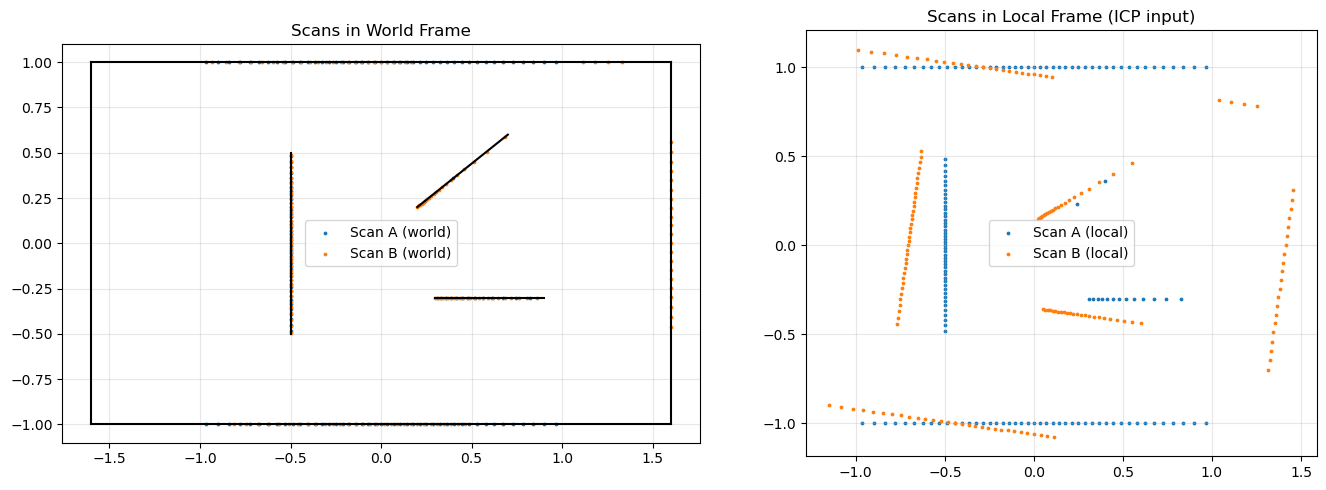

In [2]:
# Two poses: scan A (reference) and scan B (moved)
pose_A = np.array([0.0, 0.0, 0.0])
pose_B = np.array([0.2, 0.05, np.radians(8)])

# Simulate 180-ray LiDAR scans from each pose
_, _, pts_world_A = simulate_lidar(pose_A, ALL_SEGMENTS, n_rays=180)
_, _, pts_world_B = simulate_lidar(pose_B, ALL_SEGMENTS, n_rays=180)

# Convert to each robot's local frame (this is what ICP works with)
scan_A = world_to_local(pts_world_A, pose_A)
scan_B = world_to_local(pts_world_B, pose_B)

# The ground-truth relative transform (what ICP should recover)
aTb_gt = gtsam.Pose2(*pose_A).between(gtsam.Pose2(*pose_B))
print(f"Ground truth aTb: tx={aTb_gt.x():.3f}, ty={aTb_gt.y():.3f}, rot={np.degrees(aTb_gt.theta()):.1f} deg")
print(f"Scan A: {scan_A.shape[0]} points, Scan B: {scan_B.shape[0]} points")
print(f"NaN points in A: {np.isnan(scan_A).any(axis=1).sum()}, in B: {np.isnan(scan_B).any(axis=1).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for seg in ALL_SEGMENTS:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 'k-', lw=1.5)
ax.scatter(*pts_world_A.T, s=3, label='Scan A (world)')
ax.scatter(*pts_world_B.T, s=3, label='Scan B (world)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(); ax.set_title('Scans in World Frame')

ax = axes[1]
ax.scatter(scan_A[:, 0], scan_A[:, 1], s=3, label='Scan A (local)')
ax.scatter(scan_B[:, 0], scan_B[:, 1], s=3, label='Scan B (local)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(); ax.set_title('Scans in Local Frame (ICP input)')
plt.tight_layout()
plt.show()

### Real LiDAR scans (Deutsches Museum)

These are real 2D scans from a SICK LMS-151 laser scanner carried through the [Deutsches Museum](https://en.wikipedia.org/wiki/Deutsches_Museum) in Munich (from the [Google Cartographer](https://google-cartographer-ros.readthedocs.io/en/latest/data.html) public dataset). Each scan has ~1000 points, 270° field of view, 0.25° angular resolution.

We use part of the recording, approximately 175 scans covering ~120 seconds of the walk through the museum.

Full dataset: 529 scans (360s)
Using last fifth: 106 scans (73s)
Scan shape example: (996, 2)
Time between consecutive scans: ~0.69s


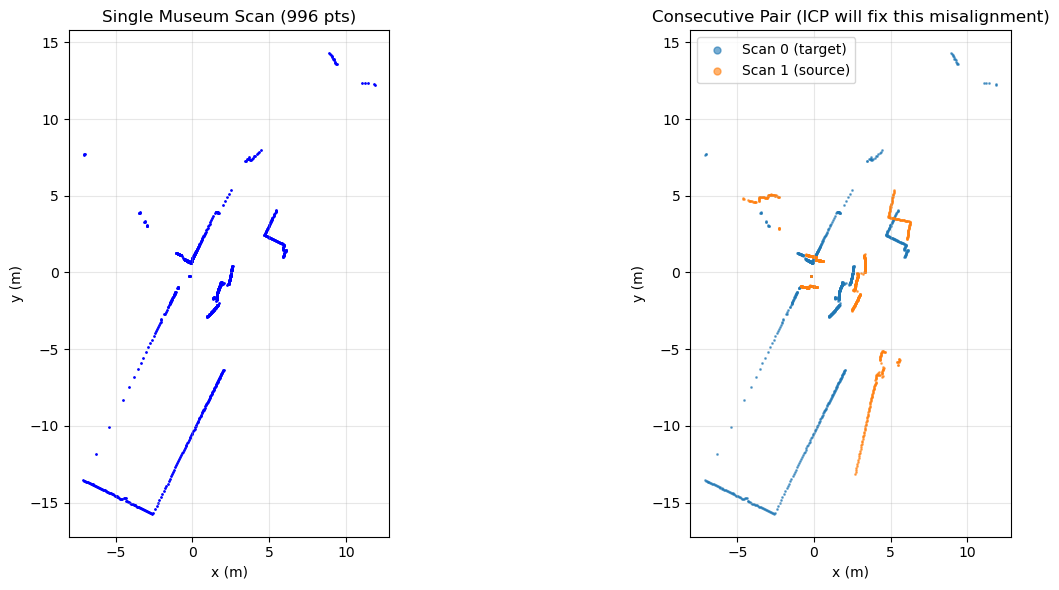

In [3]:
# Load real lidar dataset
museum_data = np.load("../data/real_lidar/deutsches_museum_scans.npz", allow_pickle=True)
all_scans = museum_data["scans"]
all_timestamps = museum_data["timestamps"]

# Use the last fifth of the recording
start = len(all_scans) * 4 // 5
museum_scans = all_scans[start:]
museum_timestamps = all_timestamps[start:]

print(f"Full dataset: {len(all_scans)} scans ({all_timestamps[-1] - all_timestamps[0]:.0f}s)")
print(f"Using last fifth: {len(museum_scans)} scans ({museum_timestamps[-1] - museum_timestamps[0]:.0f}s)")
print(f"Scan shape example: {museum_scans[0].shape}")
print(f"Time between consecutive scans: ~{np.diff(museum_timestamps).mean():.2f}s")

# Plot a single scan and a consecutive pair
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
s = museum_scans[0]
ax.scatter(s[:, 0], s[:, 1], s=1, c='blue')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title(f'Single Museum Scan ({s.shape[0]} pts)')

ax = axes[1]
s1, s2 = museum_scans[0], museum_scans[1]
ax.scatter(s1[:, 0], s1[:, 1], s=1, alpha=0.6, label='Scan 0 (target)')
ax.scatter(s2[:, 0], s2[:, 1], s=1, alpha=0.6, label='Scan 1 (source)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(markerscale=5)
ax.set_title('Consecutive Pair (ICP will fix this misalignment)')

plt.tight_layout()
plt.show()

## Task 1 Find Correspondences (3 pts)

**Implement `find_correspondences`** in `p3_lib/icp.py`.

Given a source point cloud and a KD-tree built on the target cloud, find the nearest neighbor for each source point and filter out bad matches.

**Inputs:**
- `source_points`: `(N, 2)` array - source cloud (NaN already filtered out)
- `target_tree`: `scipy.spatial.KDTree` built on target points
- `max_corr_dist`: `float` - reject matches farther than this distance

**Returns:**
- `src_matched`: `(K, 2)` - source points that have valid matches
- `tgt_matched`: `(K, 2)` - corresponding target points (same ordering, one-to-one)

**Steps:**
1. Query `target_tree.query(source_points)` to get distances and indices for each source point's nearest neighbor
2. Create a boolean mask. Keep only pairs where distance < `max_corr_dist`
3. Return the filtered source and target point arrays

Why filter by distance? Even after NaN filtering, not all correspondences are good. If scan A sees a corner that scan B doesn't (partial overlap), those points get matched to the nearest, but wrong, target point. `max_corr_dist` rejects these outliers.

In [4]:
# Test Task 1: find_correspondences

target_pts = np.array([[0, 0], [1, 0], [0, 1], [1, 1]], dtype=float)
source_pts = np.array([[0.05, 0.05], [1.1, -0.1], [5.0, 5.0]], dtype=float)  # last point is far away
tree = KDTree(target_pts)

src_m, tgt_m = find_correspondences(source_pts, tree, max_corr_dist=0.5)

assert src_m.shape[0] == 2, f"Expected 2 matches (third point too far), got {src_m.shape[0]}"
assert tgt_m.shape[0] == 2
assert np.allclose(tgt_m[0], [0, 0]), f"First source point should match (0,0), got {tgt_m[0]}"
assert np.allclose(tgt_m[1], [1, 0]), f"Second source point should match (1,0), got {tgt_m[1]}"

print("Task 1 tests passed!")

Task 1 tests passed!


## Task 2  Compute Best-Fit Transform (1 pt)

**Implement `compute_transform`** in `p3_lib/icp.py`.

Given matched point pairs, compute the rigid transform (rotation + translation) that best aligns source to target.

**Hint:`gtsam.Pose2.Align()`** computes the optimal rigid transform via SVD.

**Inputs:**
- `src_matched`: `(K, 2)` - matched source points
- `tgt_matched`: `(K, 2)` - matched target points (same ordering)

**Returns:**
- `aTb`: `gtsam.Pose2` - transform from source frame to target frame, or `None` if alignment fails (e.g., collinear points)

**Steps:**
1. Call `gtsam.Pose2.Align(tgt_matched.T, src_matched.T)`. This takes two `(2, K)` arrays (note the transpose!) and returns the transform mapping source -> target.
   - First argument: target points as `(2, K)` array
   - Second argument: source points as `(2, K)` array
2. Return the transform (handle the case where `Align` returns `None`)

In [5]:
# Test Task 2: compute_transform

# Create a known transform: rotate 15 deg + translate (0.2, 0.1)
theta_test = np.radians(15)
R_test = np.array([[np.cos(theta_test), -np.sin(theta_test)],
                    [np.sin(theta_test),  np.cos(theta_test)]])
t_test = np.array([0.2, 0.1])

# Source points (frame B)
src_pts = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1]], dtype=float)
# Target points (frame A) = R * src + t  (i.e., aTb applied to source gives target)
tgt_pts = (R_test @ src_pts.T).T + t_test

aTb_test = compute_transform(src_pts, tgt_pts)

assert aTb_test is not None, "compute_transform returned None"
assert abs(aTb_test.x() - t_test[0]) < 0.01, f"tx error: expected {t_test[0]:.3f}, got {aTb_test.x():.3f}"
assert abs(aTb_test.y() - t_test[1]) < 0.01, f"ty error: expected {t_test[1]:.3f}, got {aTb_test.y():.3f}"
assert abs(np.degrees(aTb_test.theta()) - 15.0) < 0.1, f"rot error: expected 15.0 deg, got {np.degrees(aTb_test.theta()):.2f}"

# applying the transform to source should give target
src_transformed = apply_pose2(aTb_test, src_pts)
err = np.mean(np.linalg.norm(tgt_pts - src_transformed, axis=1))
assert err < 1e-6, f"Transform error too large: {err:.6f}"

print(f"Recovered: tx={aTb_test.x():.3f}, ty={aTb_test.y():.3f}, rot={np.degrees(aTb_test.theta()):.1f} deg")
print(f"Mean alignment error: {err:.2e}")
print("Task 2 tests passed!")

Recovered: tx=0.200, ty=0.100, rot=15.0 deg
Mean alignment error: 0.00e+00
Task 2 tests passed!


## Task 3 The ICP Loop (6 pts)

**Implement `icp`** in `p3_lib/icp.py`.

Combine `find_correspondences` and `compute_transform` into the full iterative algorithm.

**Inputs:**
- `source`: `(N, 2)` - point cloud in frame B (to be aligned). May contain NaN.
- `target`: `(M, 2)` - point cloud in frame A (reference). May contain NaN.
- `tolerance`: stop when the step transform is smaller than this (both translation and rotation)
- `max_corr_dist`: passed to `find_correspondences`
- `initial_guess`: `gtsam.Pose2` or `None`. If provided, pre-transform source by this before iterating.

**Returns:**
- `aTb`: `gtsam.Pose2` - total transform from B to A
- `mean_error`: `float` - final mean correspondence distance

**Steps:**
1. Filter NaN points from both source and target
2. If `initial_guess` is provided, pre-transform source using `apply_pose2` and set `aTb_total = initial_guess`. Otherwise `aTb_total = gtsam.Pose2()` (identity).
3. Build a `KDTree` on the (filtered) target
4. Loop (until converged):
   - Call `find_correspondences` to get matched pairs
   - If fewer than 3 matches, break (can't determine a 2D rigid transform from < 3 points)
   - Call `compute_transform` on the matches to get `aTb_step`
   - If `compute_transform` returned `None`, break
   - Apply `aTb_step` to the source points using `apply_pose2`
   - Compose: `aTb_total = aTb_step.compose(aTb_total)`
   - Compute mean error from the correspondence distances
   - Check convergence: if the step transform is negligibly small (both translation magnitude and rotation magnitude < `tolerance`), break
5. Return `(aTb_total, mean_error)`

In [6]:
# Test Task 3a: Identity test
# ICP on the same cloud should return identity transform and ~zero error

cloud = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [0.5, 0.5]], dtype=float)
aTb_id, err_id = icp(cloud, cloud.copy(), max_corr_dist=0.5)

assert abs(aTb_id.x()) < 0.01, f"Identity test: tx should be ~0, got {aTb_id.x():.4f}"
assert abs(aTb_id.y()) < 0.01, f"Identity test: ty should be ~0, got {aTb_id.y():.4f}"
assert abs(aTb_id.theta()) < 0.01, f"Identity test: rot should be ~0, got {np.degrees(aTb_id.theta()):.2f} deg"
assert err_id < 0.01, f"Identity test: error should be ~0, got {err_id:.6f}"

print(f"Identity test: aTb=({aTb_id.x():.4f}, {aTb_id.y():.4f}, {np.degrees(aTb_id.theta()):.2f} deg), err={err_id:.2e}")
print("Test 3a passed!")

Identity test: aTb=(0.0000, 0.0000, 0.00 deg), err=0.00e+00
Test 3a passed!


In [7]:
# Test Task 3b: Known transform recovery
# Apply a known transform to a cloud, then verify ICP recovers it

theta_known = np.radians(12)
R_known = np.array([[np.cos(theta_known), -np.sin(theta_known)],
                     [np.sin(theta_known),  np.cos(theta_known)]])
t_known = np.array([0.15, -0.08])

# source is in frame B, target in frame A
# aTb maps B -> A: a_point = aTb * b_point
# so target_cloud = R * source_cloud + t
source_cloud = np.array([[0, 0], [1, 0], [2, 0], [0, 1], [1, 1],
                          [2, 1], [0, 2], [1, 2], [2, 2]], dtype=float)
target_cloud = (R_known @ source_cloud.T).T + t_known

aTb_recov, err_recov = icp(source_cloud, target_cloud, max_corr_dist=1.0)

pos_err = np.sqrt((aTb_recov.x() - t_known[0])**2 + (aTb_recov.y() - t_known[1])**2)
ang_err = abs(np.degrees(aTb_recov.theta()) - np.degrees(theta_known))

assert pos_err < 0.05, f"Position error too large: {pos_err:.4f}m"
assert ang_err < 1.0, f"Angle error too large: {ang_err:.2f} deg"

print(f"Known transform: tx={t_known[0]:.3f}, ty={t_known[1]:.3f}, rot={np.degrees(theta_known):.1f} deg")
print(f"Recovered:       tx={aTb_recov.x():.3f}, ty={aTb_recov.y():.3f}, rot={np.degrees(aTb_recov.theta()):.1f} deg")
print(f"Errors: position={pos_err:.4f}m, angle={ang_err:.2f} deg")
print("Test 3b passed!")

Known transform: tx=0.150, ty=-0.080, rot=12.0 deg
Recovered:       tx=0.150, ty=-0.080, rot=12.0 deg
Errors: position=0.0000m, angle=0.00 deg
Test 3b passed!


In [8]:
# Test Task 3c: ICP on simulated scans
# Uses scan_A and scan_B generated earlier

aTb_rob, err_rob = icp(scan_B, scan_A, max_corr_dist=0.3)

pos_err_rob = np.sqrt((aTb_rob.x() - aTb_gt.x())**2 + (aTb_rob.y() - aTb_gt.y())**2)
ang_err_rob = abs(np.degrees(aTb_rob.theta() - aTb_gt.theta()))

print(f"Ground truth: tx={aTb_gt.x():.3f}, ty={aTb_gt.y():.3f}, rot={np.degrees(aTb_gt.theta()):.1f} deg")
print(f"ICP result:   tx={aTb_rob.x():.3f}, ty={aTb_rob.y():.3f}, rot={np.degrees(aTb_rob.theta()):.1f} deg")
print(f"Errors: position={pos_err_rob:.4f}m, angle={ang_err_rob:.2f} deg")
print(f"Mean correspondence error: {err_rob:.4f}m")

assert pos_err_rob < 0.05, f"Position error too large: {pos_err_rob:.4f}m (expected < 0.05)"
assert ang_err_rob < 2.0, f"Angle error too large: {ang_err_rob:.2f} deg (expected < 2.0)"

print("Test 3c passed!")

Ground truth: tx=0.200, ty=0.050, rot=8.0 deg
ICP result:   tx=0.187, ty=0.049, rot=9.3 deg
Errors: position=0.0126m, angle=1.28 deg
Mean correspondence error: 0.0246m
Test 3c passed!


## Testing on Simulated Data

**Run the cell below** to visualize ICP alignment on the simulated scan pair. You should see the scans snap together in the "After" panel.

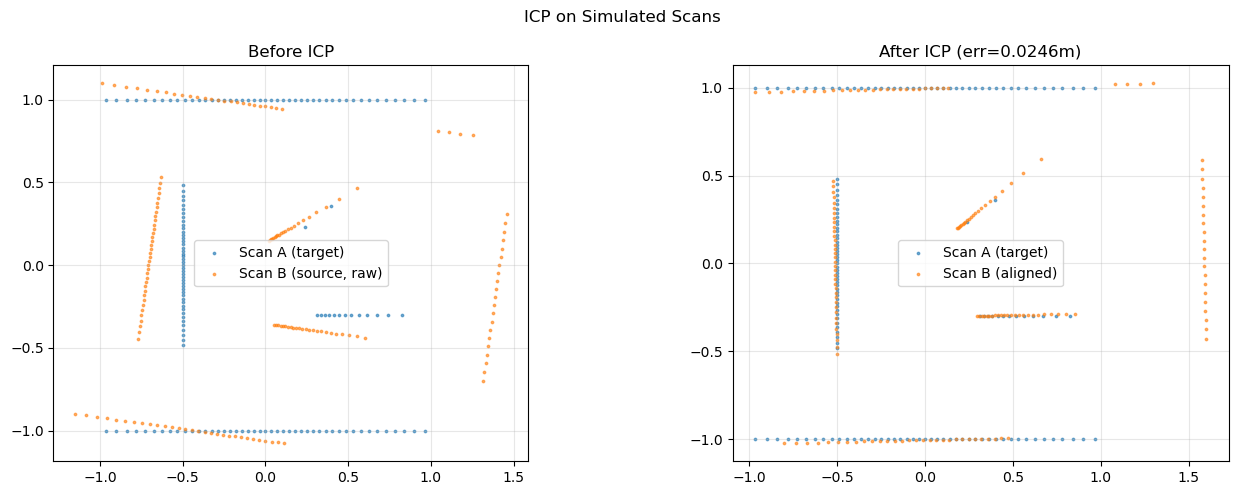

In [9]:
# Visualize ICP on simulated scans
scan_B_aligned = apply_pose2(aTb_rob, scan_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
ax = axes[0]
ax.scatter(scan_A[:, 0], scan_A[:, 1], s=3, alpha=0.6, label='Scan A (target)')
ax.scatter(scan_B[:, 0], scan_B[:, 1], s=3, alpha=0.6, label='Scan B (source, raw)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('Before ICP')

# After
ax = axes[1]
ax.scatter(scan_A[:, 0], scan_A[:, 1], s=3, alpha=0.6, label='Scan A (target)')
ax.scatter(scan_B_aligned[:, 0], scan_B_aligned[:, 1], s=3, alpha=0.6, label='Scan B (aligned)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title(f'After ICP (err={err_rob:.4f}m)')

plt.suptitle('ICP on Simulated Scans')
plt.tight_layout()
plt.show()

## Testing on Real LiDAR Data

**Run the cell below** to test your ICP on real Deutsches Museum scans. Since we don't have ground-truth poses for the museum data, we verify visually. The wall segments should overlap after alignment.

Note: use `max_corr_dist=1.0` for the museum scans (the environment is much larger than the simulated arena).

ICP result: tx=-0.720, ty=-0.039, rot=-14.27 deg
Mean correspondence error: 0.1785m


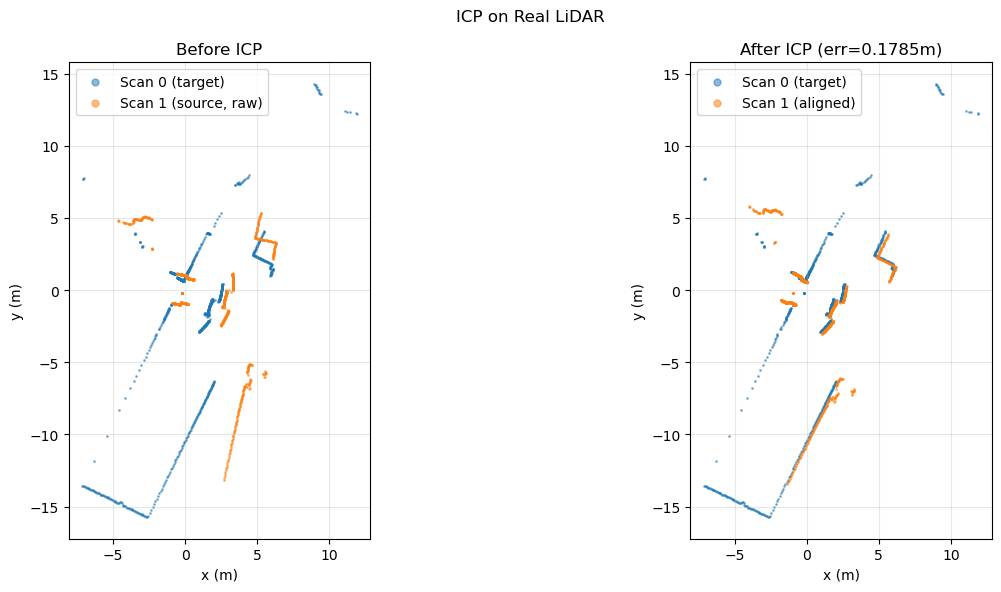

In [10]:
# ICP on real museum scans of consecutive pair
idx_a, idx_b = 0, 1
real_A = museum_scans[idx_a]
real_B = museum_scans[idx_b]

aTb_real, err_real = icp(real_B, real_A, max_corr_dist=1.0)
real_B_aligned = apply_pose2(aTb_real, real_B)

print(f"ICP result: tx={aTb_real.x():.3f}, ty={aTb_real.y():.3f}, rot={np.degrees(aTb_real.theta()):.2f} deg")
print(f"Mean correspondence error: {err_real:.4f}m")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(real_A[:, 0], real_A[:, 1], s=1, alpha=0.5, label=f'Scan {idx_a} (target)')
ax.scatter(real_B[:, 0], real_B[:, 1], s=1, alpha=0.5, label=f'Scan {idx_b} (source, raw)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(markerscale=5)
ax.set_title('Before ICP'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

ax = axes[1]
ax.scatter(real_A[:, 0], real_A[:, 1], s=1, alpha=0.5, label=f'Scan {idx_a} (target)')
ax.scatter(real_B_aligned[:, 0], real_B_aligned[:, 1], s=1, alpha=0.5, label=f'Scan {idx_b} (aligned)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(markerscale=5)
ax.set_title(f'After ICP (err={err_real:.4f}m)'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('ICP on Real LiDAR')
plt.tight_layout()
plt.show()

**Challenge:** Try a larger gap, say scans 0 and 5 (5-scan gap, ~3.5 seconds apart). Does ICP still converge? What about a gap of 10 or 20?

In [11]:
# Try it! experiment with different scan gaps
for gap in [5, 10, 20]:
    sa = museum_scans[0]
    sb = museum_scans[gap]
    dt = museum_timestamps[gap] - museum_timestamps[0]
    pose, e = icp(sb, sa, max_corr_dist=1.0)
    print(f"Gap={gap:>2} ({dt:.1f}s): tx={pose.x():+.3f} ty={pose.y():+.3f} "
          f"rot={np.degrees(pose.theta()):+.1f}deg  err={e:.4f}m")

Gap= 5 (3.5s): tx=-1.036 ty=+0.563 rot=+3.6deg  err=0.4050m
Gap=10 (7.0s): tx=-0.497 ty=+0.262 rot=-0.5deg  err=0.4195m
Gap=20 (13.9s): tx=+0.448 ty=-0.258 rot=+5.9deg  err=0.2774m


## Build a Map from Real Scans

Now for the payoff, chain your ICP across many consecutive scans to build an actual map of part of the Deutsches Museum.

Each consecutive scan pair gives a relative transform via ICP. Composing them gives each scan's pose in a shared coordinate frame. Transforming every scan's points into that frame and overlaying them produces a map.

**Run the cell below** to build a map from all the museum scans. This may take a minute.

Chaining ICP across 106 scans...
	50/106 scans processed, avg ICP error: 0.1274m
	100/106 scans processed, avg ICP error: 0.0965m
Done! Mean ICP error across all pairs: 0.1068m


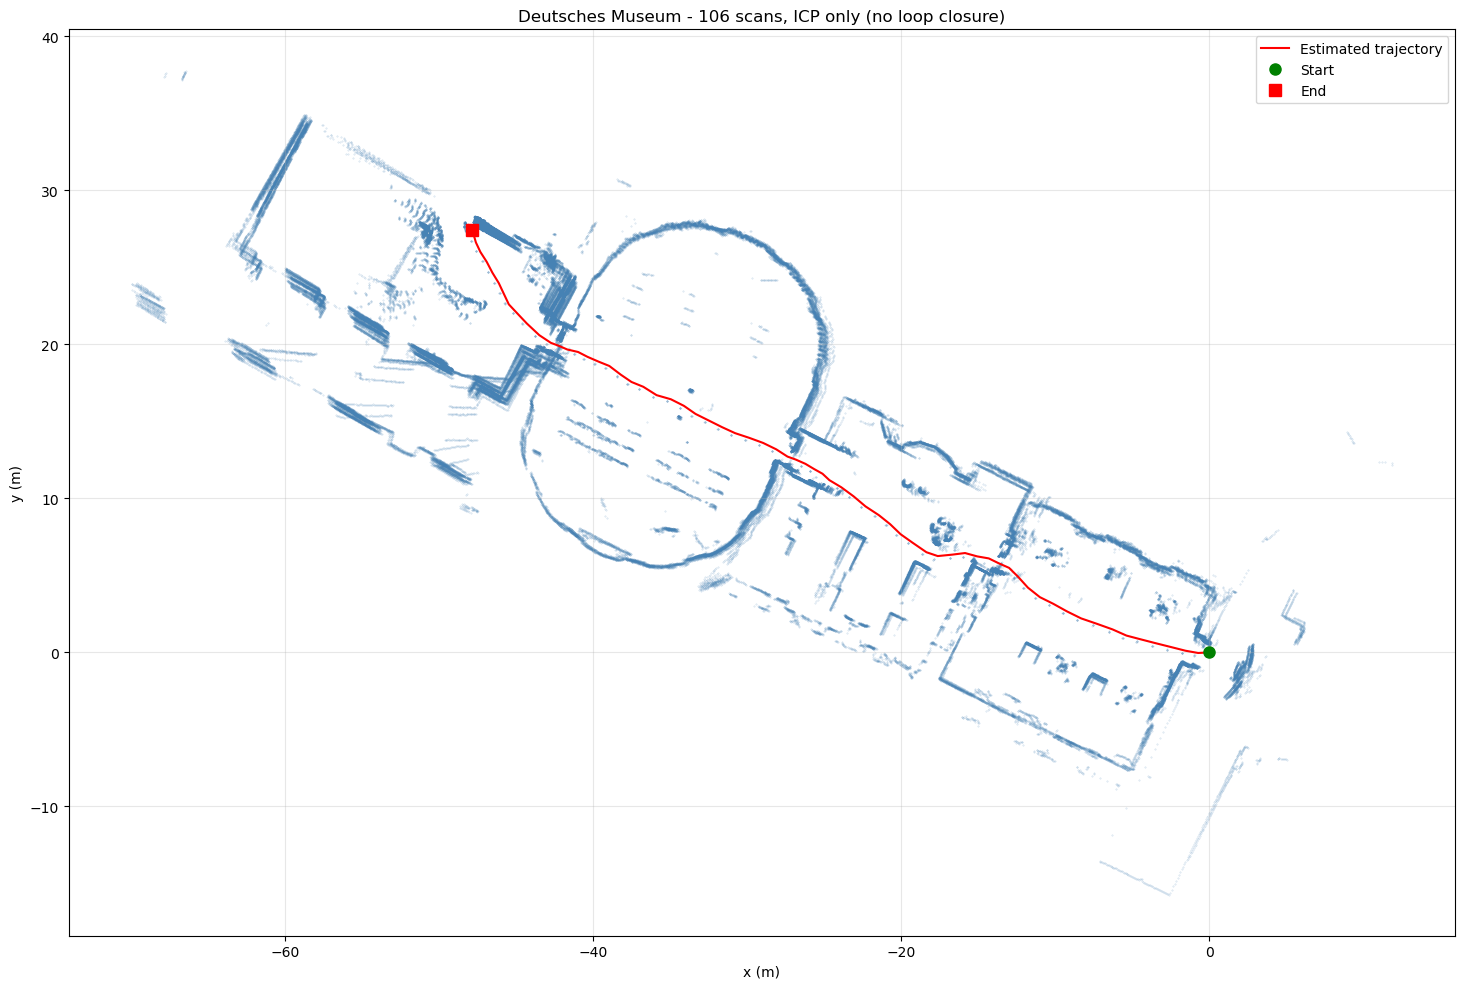

In [12]:
# Build a map by chaining consecutive ICP results
n_scans = len(museum_scans)
poses = [gtsam.Pose2()]  # scan 0 is at the origin
errors = []

print(f"Chaining ICP across {n_scans} scans...")
for i in range(1, n_scans):
    aTb, err = icp(museum_scans[i], museum_scans[i - 1], max_corr_dist=1.0)
    poses.append(poses[-1].compose(aTb))
    errors.append(err)
    if (i + 1) % 50 == 0:
        print(f"\t{i + 1}/{n_scans} scans processed, avg ICP error: {np.mean(errors[-50:]):.4f}m")

print(f"Done! Mean ICP error across all pairs: {np.mean(errors):.4f}m")

# Build the merged point cloud map
all_map_pts = []
for pose, scan in zip(poses, museum_scans):
    pts_world = apply_pose2(pose, scan)
    mask = ~np.isnan(pts_world).any(axis=1)
    all_map_pts.append(pts_world[mask])

map_pts = np.vstack(all_map_pts)
trajectory = np.array([[p.x(), p.y()] for p in poses])

# Plot the map
fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(map_pts[:, 0], map_pts[:, 1], s=0.1, c='steelblue', alpha=0.3)
ax.plot(trajectory[:, 0], trajectory[:, 1], 'r-', lw=1.5, label='Estimated trajectory')
ax.plot(trajectory[0, 0], trajectory[0, 1], 'go', ms=8, label='Start')
ax.plot(trajectory[-1, 0], trajectory[-1, 1], 'rs', ms=8, label='End')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'Deutsches Museum - {n_scans} scans, ICP only (no loop closure)')
plt.tight_layout()
plt.show()

You just built a map of part of the Deutsches Museum using nothing but laser scans and your ICP implementation.

Notice the **drift**. Since we're just chaining relative transforms, small errors accumulate over time. The map may look clean early on but become increasingly distorted. Walls that should be straight might curve, and rooms that should be closed might not line up.

This is what SLAM solves: by detecting when the robot revisits a place (loop closure) and adding those constraints to a factor graph, the accumulated drift gets corrected and the map becomes globally consistent.

## Tips and Common Issues

- **Filter NaN before building KDTree**: `KDTree` will crash on NaN input. Strip NaN rows first: `mask = ~np.isnan(pts).any(axis=1); pts_clean = pts[mask]`

- **Check that `gtsam.Pose2.Align()` didn't return `None`**: this happens when points are collinear (all on a line). In that case, break out of the ICP loop.

- **Compose order matters**: `aTb_total = aTb_step.compose(aTb_total)`. Each step's transform is composed *on the left* because it applies to the already-transformed source points.

- **`max_corr_dist` is crucial for partial overlap**: too large admits bad matches from non-overlapping regions; too small rejects good matches that are slightly off. Use `0.3` for small environments (like the simulated arena), `1.0` for the museum.

- **ICP needs at least 3 matched points** to determine a 2D rigid transform (2 translation + 1 rotation DOF). If you get fewer, break.

- **Mean error should decrease monotonically**: if it increases between iterations, check your compose order and transform application.